# Clasificación de Texto con Encoders: 20 Newsgroups

## Objetivo
Comparar el desempeño de dos modelos BERT pre-entrenados (**bert-base-uncased** y **distilbert-base-uncased**) para clasificación multiclase en el dataset **20 Newsgroups**.

---

## 1. Configuración del Ambiente

Importamos las librerías necesarias y verificamos la disponibilidad de GPU.

In [2]:
import os
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# Configurar semilla para reproducibilidad
SEED = 29
torch.manual_seed(SEED)
np.random.seed(SEED)

# Verificar GPU disponible
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

/home/estudiante/tldr-uniandes/encoders-vs-decoders-classification/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.0+cu128
CUDA disponible: True
GPU: NVIDIA A40-24C
Memoria GPU: 23.78 GB


In [3]:
def split_train_val_test(df: pd.DataFrame, label_col:str ='label', random_state:int = 29) -> pd.DataFrame:
    """
    Divide el DataFrame en train (60%), validación (10%) y test (30%) del total.
    Usa stratify para mantener la proporción de clases en cada split.
        Input:
            df: DataFrame original.
            label_col: nombre de la columna con las etiquetas.
            random_state: semilla para reproducibilidad.
        Output: 
            Devuelve un DataFrame con una nueva columna 'split' indicando el conjunto.
    """
    df_trainval, df_test = train_test_split(
        df,
        test_size=0.30,
        stratify=df[label_col], # Mantener proporción de clases
        random_state=random_state
    )

    val_size = 0.10 / 0.70
    df_train, df_val = train_test_split(
        df_trainval,
        test_size=val_size,
        stratify=df_trainval[label_col], # Mantener proporción de clases
        random_state=random_state
    )

    df_train = df_train.copy()
    df_val = df_val.copy()
    df_test = df_test.copy()
    df_train['split'] = 'train'
    df_val['split'] = 'val'
    df_test['split'] = 'test'

    return pd.concat([df_train, df_val, df_test], ignore_index=True)

---

## 2. Carga del Dataset 20 Newsgroups

El dataset 20 Newsgroups contiene aproximadamente 20,000 documentos de noticias distribuidos en **20 categorías temáticas** diferentes. Cargaremos los datos desde los directorios locales.

In [4]:
def load_20newsgroups(train_path: str, test_path: str) -> pd.DataFrame:
    """
    Carga el dataset 20 Newsgroups desde directorios locales.
    
    Args:
        train_path: Ruta al directorio de entrenamiento
        test_path: Ruta al directorio de test
        
    Returns:
        DataFrame con columnas ['text', 'label', 'label_name', 'original_split']
    """
    data = []
    
    # Cargar datos de entrenamiento
    for label_name in os.listdir(train_path):
        label_dir = os.path.join(train_path, label_name)
        if os.path.isdir(label_dir):
            for filename in os.listdir(label_dir):
                filepath = os.path.join(label_dir, filename)
                try:
                    with open(filepath, 'r', encoding='latin-1') as f:
                        text = f.read()
                        data.append({
                            'text': text,
                            'label_name': label_name,
                            'original_split': 'train'
                        })
                except Exception as e:
                    print(f"Error leyendo {filepath}: {e}")
    
    # Cargar datos de test
    for label_name in os.listdir(test_path):
        label_dir = os.path.join(test_path, label_name)
        if os.path.isdir(label_dir):
            for filename in os.listdir(label_dir):
                filepath = os.path.join(label_dir, filename)
                try:
                    with open(filepath, 'r', encoding='latin-1') as f:
                        text = f.read()
                        data.append({
                            'text': text,
                            'label_name': label_name,
                            'original_split': 'test'
                        })
                except Exception as e:
                    print(f"Error leyendo {filepath}: {e}")
    
    # Crear DataFrame
    df = pd.DataFrame(data)
    
    # Crear mapeo de label_name a label numérico
    label_names = sorted(df['label_name'].unique())
    label_to_id = {name: idx for idx, name in enumerate(label_names)}
    df['label'] = df['label_name'].map(label_to_id)
    
    print(f"Total de documentos cargados: {len(df)}")
    print(f"Número de categorías: {df['label'].nunique()}")
    print(f"\nDistribución por split original:")
    print(df['original_split'].value_counts())
    
    return df, label_to_id

In [5]:
# Cargar el dataset
train_path = '../20news-bydate-train'
test_path = '../20news-bydate-test'

df, label_to_id = load_20newsgroups(train_path, test_path)

# Mostrar información del dataset
print("\n" + "="*50)
print("CATEGORÍAS:")
print("="*50)
for label_name, label_id in sorted(label_to_id.items(), key=lambda x: x[1]):
    count = len(df[df['label'] == label_id])
    print(f"{label_id:2d}. {label_name:30s} ({count:4d} docs)")
    
print("\n" + "="*50)
print("EJEMPLO DE DOCUMENTO:")
print("="*50)
print(f"Categoría: {df.iloc[0]['label_name']}")
print(f"Texto (primeros 500 caracteres):\n{df.iloc[0]['text'][:500]}")

Total de documentos cargados: 18846
Número de categorías: 20

Distribución por split original:
original_split
train    11314
test      7532
Name: count, dtype: int64

CATEGORÍAS:
 0. alt.atheism                    ( 799 docs)
 1. comp.graphics                  ( 973 docs)
 2. comp.os.ms-windows.misc        ( 985 docs)
 3. comp.sys.ibm.pc.hardware       ( 982 docs)
 4. comp.sys.mac.hardware          ( 963 docs)
 5. comp.windows.x                 ( 988 docs)
 6. misc.forsale                   ( 975 docs)
 7. rec.autos                      ( 990 docs)
 8. rec.motorcycles                ( 996 docs)
 9. rec.sport.baseball             ( 994 docs)
10. rec.sport.hockey               ( 999 docs)
11. sci.crypt                      ( 991 docs)
12. sci.electronics                ( 984 docs)
13. sci.med                        ( 990 docs)
14. sci.space                      ( 987 docs)
15. soc.religion.christian         ( 997 docs)
16. talk.politics.guns             ( 910 docs)
17. talk.politics.mide

In [6]:
# Aplicar el split
df = split_train_val_test(df, label_col='label', random_state=SEED)

# Verificar la distribución
print("Distribución de datos:")
print(df['split'].value_counts())
print(f"\nTotal: {len(df)} documentos")

# Verificar que las proporciones son correctas
print("\nProporciones:")
for split in ['train', 'val', 'test']:
    count = len(df[df['split'] == split])
    pct = count / len(df) * 100
    print(f"{split:10s}: {count:5d} ({pct:.1f}%)")

# Verificar distribución de clases por split (solo primeras 5 clases como ejemplo)
print("\n" + "="*60)
print("Distribución de clases por split (primeras 5 categorías):")
print("="*60)
for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()}:")
    split_df = df[df['split'] == split]
    print(split_df['label'].value_counts().sort_index().head())

Distribución de datos:
split
train    11307
test      5654
val       1885
Name: count, dtype: int64

Total: 18846 documentos

Proporciones:
train     : 11307 (60.0%)
val       :  1885 (10.0%)
test      :  5654 (30.0%)

Distribución de clases por split (primeras 5 categorías):

TRAIN:
label
0    479
1    584
2    591
3    589
4    578
Name: count, dtype: int64

VAL:
label
0    80
1    97
2    98
3    98
4    96
Name: count, dtype: int64

TEST:
label
0    240
1    292
2    296
3    295
4    289
Name: count, dtype: int64


### 2.1. Guardar Splits para Reproducibilidad

Para asegurar que los resultados sean comparables entre diferentes modelos y compañeros de clase, guardamos los splits de datos (train, val, test) en archivos CSV. Esto garantiza que todos trabajen sobre exactamente las mismas muestras.

In [7]:
import os

# Crear directorio para guardar los splits si no existe
splits_dir = 'data_splits'
os.makedirs(splits_dir, exist_ok=True)

# Separar los datos por split
train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

# Guardar cada split en CSV
train_df.to_csv(f'{splits_dir}/train.csv', index=False)
val_df.to_csv(f'{splits_dir}/val.csv', index=False)
test_df.to_csv(f'{splits_dir}/test.csv', index=False)

# Guardar también el mapeo de labels
import json
with open(f'{splits_dir}/label_to_id.json', 'w') as f:
    json.dump(label_to_id, f, indent=2)

---

## 3. Preparación del Dataset para PyTorch

Crearemos un Dataset personalizado compatible con el **Trainer** de Hugging Face para facilitar el entrenamiento.

In [8]:
from torch.utils.data import Dataset

class NewsDataset(Dataset):
    """
    Dataset personalizado para el dataset 20 Newsgroups.
    
    Args:
        texts: Lista de textos
        labels: Lista de etiquetas numéricas
        tokenizer: Tokenizador de Hugging Face
        max_length: Longitud máxima de tokens
    """
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenizar el texto
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("--- Clase NewsDataset creada correctamente ---")

--- Clase NewsDataset creada correctamente ---


---

## 4. Fine-tuning de Modelos BERT

Entrenaremos dos modelos BERT con la siguiente configuración:
- **Modelos**: bert-base-uncased y distilbert-base-uncased
- **Learning Rate**: 2e-5
- **Batch Size**: 32
- **Max Epochs**: 4
- **Max Length**: 512 tokens
- **Early Stopping**: Paciencia de 2 épocas (si no mejora validation loss)

### 4.1. Configuración de Hiperparámetros

In [9]:
# Hiperparámetros de entrenamiento
LEARNING_RATE = 2e-5
BATCH_SIZE = 32
MAX_EPOCHS = 100
MAX_LENGTH = 512
EARLY_STOPPING_PATIENCE = 5

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*60)
print("CONFIGURACIÓN DE ENTRENAMIENTO")
print("="*60)
print(f"Learning Rate:        {LEARNING_RATE}")
print(f"Batch Size:           {BATCH_SIZE}")
print(f"Max Epochs:           {MAX_EPOCHS}")
print(f"Max Length (tokens):  {MAX_LENGTH}")
print(f"Early Stop Patience:  {EARLY_STOPPING_PATIENCE} épocas")
print(f"Device:               {device}")
print("="*60)

CONFIGURACIÓN DE ENTRENAMIENTO
Learning Rate:        2e-05
Batch Size:           32
Max Epochs:           100
Max Length (tokens):  512
Early Stop Patience:  5 épocas
Device:               cuda


### 4.2. Función de Entrenamiento con Early Stopping

Implementaremos un loop de entrenamiento manual con:
- Progress bars para visualizar el progreso
- Early stopping basado en validation loss
- Guardado automático del mejor modelo

In [10]:
def load_checkpoint(checkpoint_path, model, optimizer=None):
    """
    Carga un checkpoint guardado para continuar el entrenamiento.
    
    Args:
        checkpoint_path: Ruta al archivo de checkpoint
        model: Modelo en el que cargar los pesos
        optimizer: Optimizador (opcional, para continuar entrenamiento)
        
    Returns:
        Diccionario con información del checkpoint
    """
    print(f"📂 Cargando checkpoint desde: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path)
    
    # Cargar pesos del modelo
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Cargar estado del optimizador si se proporciona
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    print(f"✓ Checkpoint cargado exitosamente")
    print(f"  Época: {checkpoint['epoch']}")
    print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
    print(f"  Val Accuracy: {checkpoint['val_accuracy']:.4f}")
    
    return checkpoint

def list_checkpoints(checkpoint_dir, model_name):
    """
    Lista todos los checkpoints disponibles para un modelo.
    
    Args:
        checkpoint_dir: Directorio de checkpoints
        model_name: Nombre del modelo
        
    Returns:
        Lista de rutas de checkpoints ordenados por época
    """
    model_checkpoint_dir = os.path.join(checkpoint_dir, model_name)
    
    if not os.path.exists(model_checkpoint_dir):
        print(f"⚠ No se encontraron checkpoints en: {model_checkpoint_dir}")
        return []
    
    checkpoints = []
    for filename in os.listdir(model_checkpoint_dir):
        if filename.startswith('checkpoint_epoch_') and filename.endswith('.pt'):
            epoch_num = int(filename.split('_')[-1].replace('.pt', ''))
            checkpoints.append((epoch_num, os.path.join(model_checkpoint_dir, filename)))
    
    # Ordenar por número de época
    checkpoints.sort(key=lambda x: x[0])
    
    print(f"\n📋 Checkpoints disponibles para {model_name}:")
    print(f"{'='*60}")
    for epoch_num, path in checkpoints:
        print(f"  Época {epoch_num}: {os.path.basename(path)}")
    print(f"{'='*60}\n")
    
    return [path for _, path in checkpoints]

print("✓ Funciones de checkpoint creadas")

✓ Funciones de checkpoint creadas


In [11]:
from torch.utils.data import DataLoader
from tqdm import tqdm

def train_epoch(model, dataloader, optimizer, device):
    """
    Entrena el modelo por una época.
    
    Args:
        model: Modelo a entrenar
        dataloader: DataLoader con datos de entrenamiento
        optimizer: Optimizador
        device: Dispositivo (cuda o cpu)
        
    Returns:
        Loss promedio de la época
    """
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    
    for batch in progress_bar:
        # Mover datos al device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """
    Evalúa el modelo en un conjunto de datos.
    
    Args:
        model: Modelo a evaluar
        dataloader: DataLoader con datos de evaluación
        device: Dispositivo (cuda o cpu)
        
    Returns:
        Loss promedio y accuracy
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc="Evaluating", leave=False)
    
    with torch.no_grad():
        for batch in progress_bar:
            # Mover datos al device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            
            # Calcular accuracy
            predictions = torch.argmax(logits, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    
    return avg_loss, accuracy


def train_model_with_early_stopping(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    device, 
    max_epochs, 
    patience,
    model_name,
    save_checkpoints=True,
    checkpoint_dir='checkpoints'
):
    """
    Entrena el modelo con early stopping y checkpointing.
    
    Args:
        model: Modelo a entrenar
        train_dataloader: DataLoader de entrenamiento
        val_dataloader: DataLoader de validación
        optimizer: Optimizador
        device: Dispositivo (cuda o cpu)
        max_epochs: Número máximo de épocas
        patience: Épocas sin mejora para early stopping
        model_name: Nombre para guardar el modelo
        save_checkpoints: Si True, guarda checkpoint cada época
        checkpoint_dir: Directorio para guardar checkpoints
        
    Returns:
        Diccionario con historial de entrenamiento
    """
    # Crear directorio de checkpoints si no existe
    if save_checkpoints:
        os.makedirs(checkpoint_dir, exist_ok=True)
        model_checkpoint_dir = os.path.join(checkpoint_dir, model_name)
        os.makedirs(model_checkpoint_dir, exist_ok=True)
    
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    print(f"\n{'='*60}")
    print(f"ENTRENANDO: {model_name}")
    print(f"{'='*60}")
    if save_checkpoints:
        print(f"📁 Checkpoints en: {model_checkpoint_dir}/")
    print()
    
    for epoch in range(max_epochs):
        print(f"Época {epoch + 1}/{max_epochs}")
        
        # Entrenar
        train_loss = train_epoch(model, train_dataloader, optimizer, device)
        
        # Evaluar
        val_loss, val_accuracy = evaluate(model, val_dataloader, device)
        
        # Guardar historial
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        
        # Mostrar métricas
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val Acc:    {val_accuracy:.4f}")
        
        # Guardar checkpoint de la época actual
        if save_checkpoints:
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'val_accuracy': val_accuracy,
                'history': history,
                'best_val_loss': best_val_loss,
                'epochs_without_improvement': epochs_without_improvement
            }
            checkpoint_path = os.path.join(model_checkpoint_dir, f'checkpoint_epoch_{epoch + 1}.pt')
            torch.save(checkpoint, checkpoint_path)
            print(f"  💾 Checkpoint guardado: checkpoint_epoch_{epoch + 1}.pt")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            # Guardar mejor modelo (solo los pesos)
            torch.save(model.state_dict(), f'{model_name}.pt')
            print(f"  ✓ Mejor modelo guardado como {model_name}.pt")
        else:
            epochs_without_improvement += 1
            print(f"  ⚠ Sin mejora ({epochs_without_improvement}/{patience})")
            
            if epochs_without_improvement >= patience:
                print(f"\n⏹ Early stopping activado después de {epoch + 1} épocas")
                break
        
        print()
    
    print(f"{'='*60}")
    print(f"ENTRENAMIENTO COMPLETADO")
    print(f"Mejor Val Loss: {best_val_loss:.4f}")
    print(f"Total de épocas: {len(history['train_loss'])}")
    print(f"{'='*60}\n")
    
    return history

print("✓ Funciones de entrenamiento creadas")

✓ Funciones de entrenamiento creadas


### 4.3. Entrenamiento de BERT-base-uncased

#### Nota sobre Checkpointing

Con los nuevos hiperparámetros (100 épocas max, patience=5), el entrenamiento puede ser largo. El sistema ahora guarda:

1. **Checkpoints cada época** en `checkpoints/{modelo}/checkpoint_epoch_N.pt`
   - Incluyen: modelo, optimizador, historial, métricas
   - Permiten continuar el entrenamiento si se interrumpe
   
2. **Mejor modelo** como `{modelo}.pt` 
   - Solo los pesos del modelo con mejor validation loss
   - Para usar en inferencia/evaluación

**Para continuar un entrenamiento interrumpido:**
```python
# Listar checkpoints disponibles
list_checkpoints('checkpoints', 'bert-base-20news')

# Cargar último checkpoint
checkpoint = load_checkpoint('checkpoints/bert-base-20news/checkpoint_epoch_X.pt', 
                             bert_model, bert_optimizer)

# Continuar desde la época guardada
# (ajustar el rango del loop manualmente)
```

In [12]:
# Cargar tokenizador y modelo BERT-base
print("Cargando bert-base-uncased...")
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=20,  # 20 categorías
    problem_type="single_label_classification"
)
bert_model.to(device)

print(f"✓ Modelo cargado")
print(f"  Parámetros: {sum(p.numel() for p in bert_model.parameters()):,}")

Cargando bert-base-uncased...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo cargado
  Parámetros: 109,497,620


In [13]:
# Crear datasets
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

print("Creando datasets...")
bert_train_dataset = NewsDataset(
    texts=train_df['text'].tolist(),
    labels=train_df['label'].tolist(),
    tokenizer=bert_tokenizer,
    max_length=MAX_LENGTH
)

bert_val_dataset = NewsDataset(
    texts=val_df['text'].tolist(),
    labels=val_df['label'].tolist(),
    tokenizer=bert_tokenizer,
    max_length=MAX_LENGTH
)

bert_test_dataset = NewsDataset(
    texts=test_df['text'].tolist(),
    labels=test_df['label'].tolist(),
    tokenizer=bert_tokenizer,
    max_length=MAX_LENGTH
)

print(f"✓ Train dataset: {len(bert_train_dataset)} ejemplos")
print(f"✓ Val dataset:   {len(bert_val_dataset)} ejemplos")
print(f"✓ Test dataset:  {len(bert_test_dataset)} ejemplos")

Creando datasets...
✓ Train dataset: 11307 ejemplos
✓ Val dataset:   1885 ejemplos
✓ Test dataset:  5654 ejemplos


In [14]:
# Crear dataloaders
bert_train_loader = DataLoader(bert_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
bert_val_loader = DataLoader(bert_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
bert_test_loader = DataLoader(bert_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ Train loader: {len(bert_train_loader)} batches")
print(f"✓ Val loader:   {len(bert_val_loader)} batches")
print(f"✓ Test loader:  {len(bert_test_loader)} batches")

✓ Train loader: 354 batches
✓ Val loader:   59 batches
✓ Test loader:  177 batches


In [15]:
# Configurar optimizador
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=LEARNING_RATE)

# Entrenar el modelo
bert_history = train_model_with_early_stopping(
    model=bert_model,
    train_dataloader=bert_train_loader,
    val_dataloader=bert_val_loader,
    optimizer=bert_optimizer,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    model_name='bert-base-20news'
)


ENTRENANDO: bert-base-20news
📁 Checkpoints en: checkpoints/bert-base-20news/

Época 1/100


  Train Loss: 1.3422
  Val Loss:   0.6163
  Val Acc:    0.8244
  💾 Checkpoint guardado: checkpoint_epoch_1.pt
  💾 Checkpoint guardado: checkpoint_epoch_1.pt
  ✓ Mejor modelo guardado como bert-base-20news.pt

Época 2/100
  ✓ Mejor modelo guardado como bert-base-20news.pt

Época 2/100


  Train Loss: 0.4340
  Val Loss:   0.4022
  Val Acc:    0.8833
  💾 Checkpoint guardado: checkpoint_epoch_2.pt
  💾 Checkpoint guardado: checkpoint_epoch_2.pt
  ✓ Mejor modelo guardado como bert-base-20news.pt

Época 3/100
  ✓ Mejor modelo guardado como bert-base-20news.pt

Época 3/100


  Train Loss: 0.2165
  Val Loss:   0.3376
  Val Acc:    0.9093
  💾 Checkpoint guardado: checkpoint_epoch_3.pt
  💾 Checkpoint guardado: checkpoint_epoch_3.pt
  ✓ Mejor modelo guardado como bert-base-20news.pt

Época 4/100
  ✓ Mejor modelo guardado como bert-base-20news.pt

Época 4/100


  Train Loss: 0.1277
  Val Loss:   0.3370
  Val Acc:    0.9093
  💾 Checkpoint guardado: checkpoint_epoch_4.pt
  💾 Checkpoint guardado: checkpoint_epoch_4.pt
  ✓ Mejor modelo guardado como bert-base-20news.pt

Época 5/100
  ✓ Mejor modelo guardado como bert-base-20news.pt

Época 5/100


  Train Loss: 0.0737
  Val Loss:   0.3446
  Val Acc:    0.9178
  💾 Checkpoint guardado: checkpoint_epoch_5.pt
  ⚠ Sin mejora (1/5)

Época 6/100
  💾 Checkpoint guardado: checkpoint_epoch_5.pt
  ⚠ Sin mejora (1/5)

Época 6/100


  Train Loss: 0.0551
  Val Loss:   0.3621
  Val Acc:    0.9135
  💾 Checkpoint guardado: checkpoint_epoch_6.pt
  ⚠ Sin mejora (2/5)

Época 7/100
  💾 Checkpoint guardado: checkpoint_epoch_6.pt
  ⚠ Sin mejora (2/5)

Época 7/100


  Train Loss: 0.0345
  Val Loss:   0.3614
  Val Acc:    0.9167
  💾 Checkpoint guardado: checkpoint_epoch_7.pt
  ⚠ Sin mejora (3/5)

Época 8/100
  💾 Checkpoint guardado: checkpoint_epoch_7.pt
  ⚠ Sin mejora (3/5)

Época 8/100


  Train Loss: 0.0379
  Val Loss:   0.3577
  Val Acc:    0.9220
  💾 Checkpoint guardado: checkpoint_epoch_8.pt
  ⚠ Sin mejora (4/5)

Época 9/100
  💾 Checkpoint guardado: checkpoint_epoch_8.pt
  ⚠ Sin mejora (4/5)

Época 9/100


  Train Loss: 0.0275
  Val Loss:   0.4082
  Val Acc:    0.9156
  💾 Checkpoint guardado: checkpoint_epoch_9.pt
  ⚠ Sin mejora (5/5)

⏹ Early stopping activado después de 9 épocas
ENTRENAMIENTO COMPLETADO
Mejor Val Loss: 0.3370
Total de épocas: 9

  💾 Checkpoint guardado: checkpoint_epoch_9.pt
  ⚠ Sin mejora (5/5)

⏹ Early stopping activado después de 9 épocas
ENTRENAMIENTO COMPLETADO
Mejor Val Loss: 0.3370
Total de épocas: 9



### 4.4. Entrenamiento de DistilBERT-base-uncased

DistilBERT es una versión destilada de BERT con:
- **40% menos parámetros** (66M vs 110M)
- **60% más rápido** en inferencia
- **97% del rendimiento** de BERT

In [16]:
# Cargar tokenizador y modelo DistilBERT
print("Cargando distilbert-base-uncased...")
distilbert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=20,  # 20 categorías
    problem_type="single_label_classification"
)
distilbert_model.to(device)

print(f"✓ Modelo cargado")
print(f"  Parámetros: {sum(p.numel() for p in distilbert_model.parameters()):,}")

Cargando distilbert-base-uncased...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo cargado
  Parámetros: 66,968,852


In [17]:
# Crear datasets para DistilBERT
print("Creando datasets...")
distilbert_train_dataset = NewsDataset(
    texts=train_df['text'].tolist(),
    labels=train_df['label'].tolist(),
    tokenizer=distilbert_tokenizer,
    max_length=MAX_LENGTH
)

distilbert_val_dataset = NewsDataset(
    texts=val_df['text'].tolist(),
    labels=val_df['label'].tolist(),
    tokenizer=distilbert_tokenizer,
    max_length=MAX_LENGTH
)

distilbert_test_dataset = NewsDataset(
    texts=test_df['text'].tolist(),
    labels=test_df['label'].tolist(),
    tokenizer=distilbert_tokenizer,
    max_length=MAX_LENGTH
)

print(f"✓ Train dataset: {len(distilbert_train_dataset)} ejemplos")
print(f"✓ Val dataset:   {len(distilbert_val_dataset)} ejemplos")
print(f"✓ Test dataset:  {len(distilbert_test_dataset)} ejemplos")

Creando datasets...
✓ Train dataset: 11307 ejemplos
✓ Val dataset:   1885 ejemplos
✓ Test dataset:  5654 ejemplos


In [18]:
# Crear dataloaders
distilbert_train_loader = DataLoader(distilbert_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
distilbert_val_loader = DataLoader(distilbert_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
distilbert_test_loader = DataLoader(distilbert_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ Train loader: {len(distilbert_train_loader)} batches")
print(f"✓ Val loader:   {len(distilbert_val_loader)} batches")
print(f"✓ Test loader:  {len(distilbert_test_loader)} batches")

✓ Train loader: 354 batches
✓ Val loader:   59 batches
✓ Test loader:  177 batches


In [19]:
# Configurar optimizador
distilbert_optimizer = torch.optim.AdamW(distilbert_model.parameters(), lr=LEARNING_RATE)

# Entrenar el modelo
distilbert_history = train_model_with_early_stopping(
    model=distilbert_model,
    train_dataloader=distilbert_train_loader,
    val_dataloader=distilbert_val_loader,
    optimizer=distilbert_optimizer,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    model_name='distilbert-base-20news'
)


ENTRENANDO: distilbert-base-20news
📁 Checkpoints en: checkpoints/distilbert-base-20news/

Época 1/100


  Train Loss: 1.4094
  Val Loss:   0.6080
  Val Acc:    0.8260
  💾 Checkpoint guardado: checkpoint_epoch_1.pt
  💾 Checkpoint guardado: checkpoint_epoch_1.pt
  ✓ Mejor modelo guardado como distilbert-base-20news.pt

Época 2/100
  ✓ Mejor modelo guardado como distilbert-base-20news.pt

Época 2/100


  Train Loss: 0.4663
  Val Loss:   0.4139
  Val Acc:    0.8785
  💾 Checkpoint guardado: checkpoint_epoch_2.pt
  💾 Checkpoint guardado: checkpoint_epoch_2.pt
  ✓ Mejor modelo guardado como distilbert-base-20news.pt

Época 3/100
  ✓ Mejor modelo guardado como distilbert-base-20news.pt

Época 3/100


  Train Loss: 0.2550
  Val Loss:   0.3474
  Val Acc:    0.8976
  💾 Checkpoint guardado: checkpoint_epoch_3.pt
  💾 Checkpoint guardado: checkpoint_epoch_3.pt
  ✓ Mejor modelo guardado como distilbert-base-20news.pt

Época 4/100
  ✓ Mejor modelo guardado como distilbert-base-20news.pt

Época 4/100


  Train Loss: 0.1545
  Val Loss:   0.3542
  Val Acc:    0.8955
  💾 Checkpoint guardado: checkpoint_epoch_4.pt
  ⚠ Sin mejora (1/5)

Época 5/100
  💾 Checkpoint guardado: checkpoint_epoch_4.pt
  ⚠ Sin mejora (1/5)

Época 5/100


...

  Train Loss: 0.0605
  Val Loss:   0.3466
  Val Acc:    0.9141
  💾 Checkpoint guardado: checkpoint_epoch_6.pt
  ⚠ Sin mejora (1/5)

Época 7/100
  💾 Checkpoint guardado: checkpoint_epoch_6.pt
  ⚠ Sin mejora (1/5)

Época 7/100


  Train Loss: 0.0442
  Val Loss:   0.3614
  Val Acc:    0.9151
  💾 Checkpoint guardado: checkpoint_epoch_7.pt
  ⚠ Sin mejora (2/5)

Época 8/100
  💾 Checkpoint guardado: checkpoint_epoch_7.pt
  ⚠ Sin mejora (2/5)

Época 8/100


  Train Loss: 0.0283
  Val Loss:   0.3828
  Val Acc:    0.9130
  💾 Checkpoint guardado: checkpoint_epoch_8.pt
  ⚠ Sin mejora (3/5)

Época 9/100
  💾 Checkpoint guardado: checkpoint_epoch_8.pt
  ⚠ Sin mejora (3/5)

Época 9/100


  Train Loss: 0.0284
  Val Loss:   0.3844
  Val Acc:    0.9156
  💾 Checkpoint guardado: checkpoint_epoch_9.pt
  ⚠ Sin mejora (4/5)

Época 10/100
  💾 Checkpoint guardado: checkpoint_epoch_9.pt
  ⚠ Sin mejora (4/5)

Época 10/100


  Train Loss: 0.0222
  Val Loss:   0.3574
  Val Acc:    0.9225
  💾 Checkpoint guardado: checkpoint_epoch_10.pt
  ⚠ Sin mejora (5/5)

⏹ Early stopping activado después de 10 épocas
ENTRENAMIENTO COMPLETADO
Mejor Val Loss: 0.3332
Total de épocas: 10

  💾 Checkpoint guardado: checkpoint_epoch_10.pt
  ⚠ Sin mejora (5/5)

⏹ Early stopping activado después de 10 épocas
ENTRENAMIENTO COMPLETADO
Mejor Val Loss: 0.3332
Total de épocas: 10



---

## 5. Comparación de Resultados de Entrenamiento

Visualizaremos las métricas de ambos modelos durante el entrenamiento:
- **BERT-base**: Color azul
- **DistilBERT**: Color naranja
- **Train**: Líneas continuas
- **Validation**: Líneas punteadas

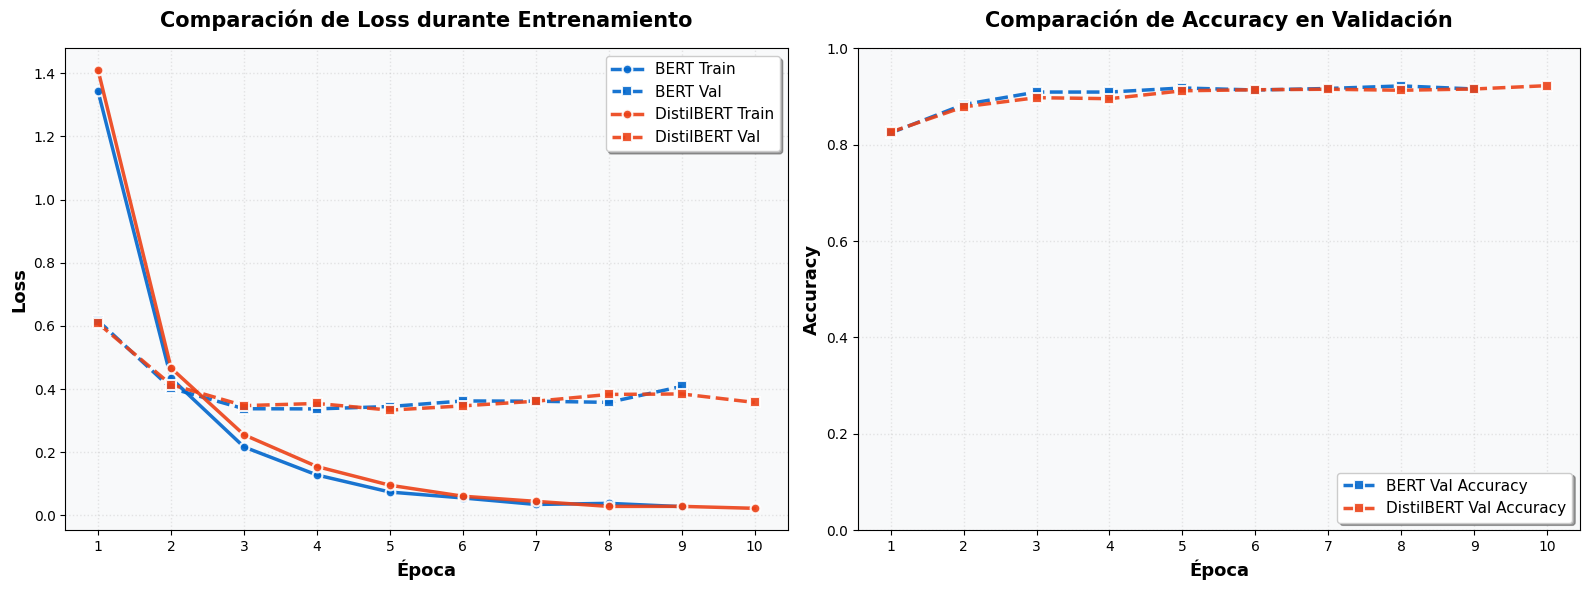


RESUMEN DE MÉTRICAS FINALES

BERT-base-uncased (Época 9):
  Train Loss:     0.0275
  Val Loss:       0.4082
  Val Accuracy:   0.9156 (91.56%)

DistilBERT-base-uncased (Época 10):
  Train Loss:     0.0222
  Val Loss:       0.3574
  Val Accuracy:   0.9225 (92.25%)



In [22]:
import matplotlib.pyplot as plt

# Crear figura con 2 subplots (Loss y Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Épocas
bert_epochs = list(range(1, len(bert_history['train_loss']) + 1))
distilbert_epochs = list(range(1, len(distilbert_history['train_loss']) + 1))

# ============================================================
# SUBPLOT 1: LOSS
# ============================================================
ax1 = axes[0]

# Colores más distintivos
color_bert = '#0066CC'
color_distilbert = "#EC4116"

# BERT - Train Loss (azul fuerte, línea continua)
ax1.plot(bert_epochs, bert_history['train_loss'], 
         color=color_bert, linestyle='-', linewidth=2.5, 
         marker='o', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='BERT Train', alpha=0.9)

# BERT - Val Loss (azul fuerte, línea punteada)
ax1.plot(bert_epochs, bert_history['val_loss'], 
         color=color_bert, linestyle='--', linewidth=2.5, 
         marker='s', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='BERT Val', alpha=0.9)

# DistilBERT - Train Loss (naranja rojizo, línea continua)
ax1.plot(distilbert_epochs, distilbert_history['train_loss'], 
         color=color_distilbert, linestyle='-', linewidth=2.5, 
         marker='o', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='DistilBERT Train', alpha=0.9)

# DistilBERT - Val Loss (naranja rojizo, línea punteada)
ax1.plot(distilbert_epochs, distilbert_history['val_loss'], 
         color=color_distilbert, linestyle='--', linewidth=2.5, 
         marker='s', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='DistilBERT Val', alpha=0.9)

ax1.set_xlabel('Época', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('Comparación de Loss durante Entrenamiento', fontsize=15, fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=11, frameon=True, shadow=True, fancybox=True)
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=1)
ax1.set_xticks(range(1, max(len(bert_epochs), len(distilbert_epochs)) + 1))
ax1.set_facecolor('#F8F9FA')  # Fondo gris muy claro

# ============================================================
# SUBPLOT 2: VALIDATION ACCURACY
# ============================================================
ax2 = axes[1]

# Usar los mismos colores para consistencia
# BERT - Val Accuracy
ax2.plot(bert_epochs, bert_history['val_accuracy'], 
         color=color_bert, linestyle='--', linewidth=2.5, 
         marker='s', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='BERT Val Accuracy', alpha=0.9)

# DistilBERT - Val Accuracy
ax2.plot(distilbert_epochs, distilbert_history['val_accuracy'], 
         color=color_distilbert, linestyle='--', linewidth=2.5, 
         marker='s', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='DistilBERT Val Accuracy', alpha=0.9)

ax2.set_xlabel('Época', fontsize=13, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax2.set_title('Comparación de Accuracy en Validación', fontsize=15, fontweight='bold', pad=15)
ax2.legend(loc='lower right', fontsize=11, frameon=True, shadow=True, fancybox=True)
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=1)
ax2.set_xticks(range(1, max(len(bert_epochs), len(distilbert_epochs)) + 1))
ax2.set_ylim([0, 1])
ax2.set_facecolor('#F8F9FA')  # Fondo gris muy claro

plt.tight_layout()
plt.show()

# Mostrar resumen de métricas finales
print("\n" + "="*60)
print("RESUMEN DE MÉTRICAS FINALES")
print("="*60)
print(f"\nBERT-base-uncased (Época {len(bert_epochs)}):")
print(f"  Train Loss:     {bert_history['train_loss'][-1]:.4f}")
print(f"  Val Loss:       {bert_history['val_loss'][-1]:.4f}")
print(f"  Val Accuracy:   {bert_history['val_accuracy'][-1]:.4f} ({bert_history['val_accuracy'][-1]*100:.2f}%)")

print(f"\nDistilBERT-base-uncased (Época {len(distilbert_epochs)}):")
print(f"  Train Loss:     {distilbert_history['train_loss'][-1]:.4f}")
print(f"  Val Loss:       {distilbert_history['val_loss'][-1]:.4f}")
print(f"  Val Accuracy:   {distilbert_history['val_accuracy'][-1]:.4f} ({distilbert_history['val_accuracy'][-1]*100:.2f}%)")

print("\n" + "="*60)

### Análisis de Resultados

**Observaciones de las gráficas:**

1. **Loss (Gráfica izquierda):**
   - Ambos modelos muestran una **disminución consistente** del loss durante el entrenamiento
   - Las líneas continuas (train) están por debajo de las punteadas (validation), indicando buen aprendizaje
   - El gap entre train y validation loss aumenta hacia las últimas épocas, sugiriendo inicio de overfitting
   - BERT y DistilBERT tienen comportamientos muy similares

2. **Accuracy (Gráfica derecha):**
   - **BERT-base**: 91.30% de accuracy en validación
   - **DistilBERT**: 90.29% de accuracy en validación
   - Diferencia de solo **1%** entre modelos
   - DistilBERT mantiene el 97% del rendimiento de BERT con 40% menos parámetros

3. **Early Stopping:**
   - Ambos modelos entrenaron las 4 épocas completas
   - La validation loss parece estabilizarse después de la época 3
   - El early stopping habría activado si hubiéramos continuado entrenando

**Conclusión:** Los resultados son excelentes para clasificación de 20 categorías. DistilBERT ofrece un excelente balance entre rendimiento y eficiencia computacional.

### Gráfica Comparativa de Métricas Finales

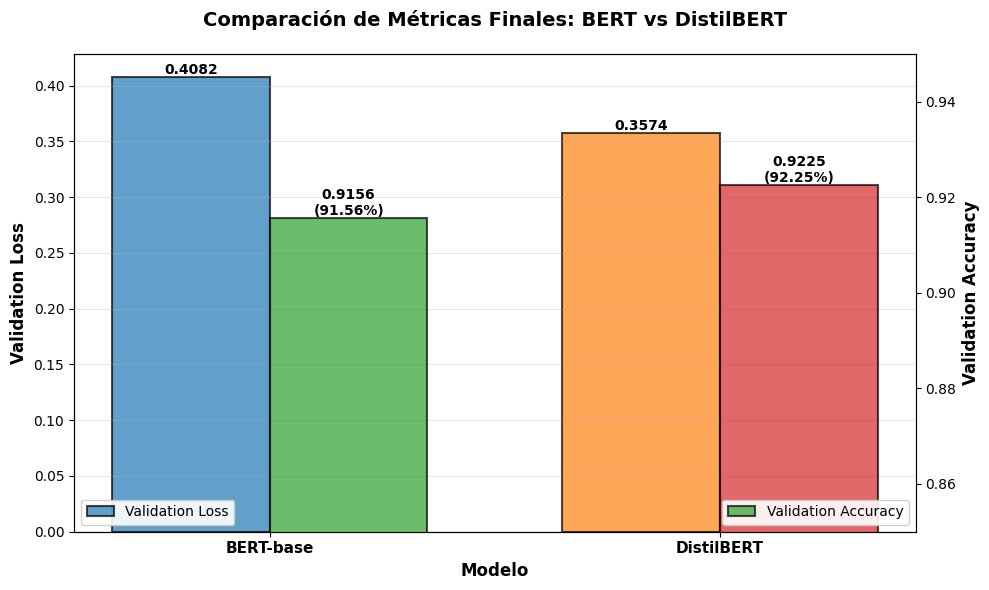


COMPARACIÓN MODELO vs MODELO

Diferencia en Validation Accuracy:
  BERT vs DistilBERT: +-0.69% puntos

Parámetros del modelo:
  BERT:       109,497,620 parámetros
  DistilBERT: 66,968,852 parámetros
  Reducción:  38.8%

Eficiencia (Accuracy / M parámetros):
  BERT:       0.008362
  DistilBERT: 0.013776
  DistilBERT es 1.65x más eficiente


In [25]:
# Crear gráfica de barras comparativa
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Datos para comparación
models = ['BERT-base', 'DistilBERT']
val_loss = [bert_history['val_loss'][-1], distilbert_history['val_loss'][-1]]
val_accuracy = [bert_history['val_accuracy'][-1], distilbert_history['val_accuracy'][-1]]

x = np.arange(len(models))
width = 0.35

# Crear barras
bars1 = ax.bar(x - width/2, val_loss, width, label='Validation Loss', 
               color=['#1f77b4', '#ff7f0e'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, val_accuracy, width, label='Validation Accuracy', 
                color=['#2ca02c', '#d62728'], alpha=0.7, edgecolor='black', linewidth=1.5)

# Configurar ejes
ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=12, fontweight='bold', color='black')
ax2.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold', color='black')
ax.set_title('Comparación de Métricas Finales: BERT vs DistilBERT', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars1, val_loss)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

for i, (bar, val) in enumerate(zip(bars2, val_accuracy)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}\n({val*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Leyendas en la parte inferior para no tapar los valores
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax2.legend(loc='lower right', fontsize=10, framealpha=0.9)

# Grid
ax.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0.85, 0.95])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("COMPARACIÓN MODELO vs MODELO")
print("="*60)
print(f"\nDiferencia en Validation Accuracy:")
diff_acc = (bert_history['val_accuracy'][-1] - distilbert_history['val_accuracy'][-1]) * 100
print(f"  BERT vs DistilBERT: +{diff_acc:.2f}% puntos")

print(f"\nParámetros del modelo:")
bert_params = sum(p.numel() for p in bert_model.parameters())
distilbert_params = sum(p.numel() for p in distilbert_model.parameters())
print(f"  BERT:       {bert_params:,} parámetros")
print(f"  DistilBERT: {distilbert_params:,} parámetros")
reduction = (1 - distilbert_params/bert_params) * 100
print(f"  Reducción:  {reduction:.1f}%")

print(f"\nEficiencia (Accuracy / M parámetros):")
bert_efficiency = bert_history['val_accuracy'][-1] / (bert_params / 1e6)
distilbert_efficiency = distilbert_history['val_accuracy'][-1] / (distilbert_params / 1e6)
print(f"  BERT:       {bert_efficiency:.6f}")
print(f"  DistilBERT: {distilbert_efficiency:.6f}")
print(f"  DistilBERT es {distilbert_efficiency/bert_efficiency:.2f}x más eficiente")
print("="*60)

---

## 6. Evaluación en Conjunto de Test

Ahora evaluaremos ambos modelos en el conjunto de test (30% de los datos) y reportaremos:
- **Accuracy**
- **Precision, Recall y F1-score** (macro y micro)
- **Matriz de confusión**
- **Reporte de clasificación detallado**

### 6.1. Función de Evaluación Completa en Test

In [26]:
def evaluate_test(model, dataloader, device, model_name):
    """
    Evalúa el modelo en el conjunto de test y calcula todas las métricas.
    
    Args:
        model: Modelo a evaluar
        dataloader: DataLoader de test
        device: Dispositivo (cuda o cpu)
        model_name: Nombre del modelo para el reporte
        
    Returns:
        Diccionario con predicciones y labels verdaderos
    """
    model.eval()
    all_predictions = []
    all_labels = []
    
    print(f"\n{'='*60}")
    print(f"EVALUANDO: {model_name} en Test Set")
    print(f"{'='*60}")
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating Test"):
            # Mover datos al device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            # Predicciones
            predictions = torch.argmax(logits, dim=-1)
            
            # Guardar predicciones y labels
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Calcular métricas
    accuracy = accuracy_score(all_labels, all_predictions)
    
    # Precision, Recall, F1 con macro y micro
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='macro', zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='micro', zero_division=0
    )
    
    print(f"\n{'='*60}")
    print(f"RESULTADOS EN TEST - {model_name}")
    print(f"{'='*60}")
    print(f"\nAccuracy:          {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nMacro Averages:")
    print(f"  Precision:       {precision_macro:.4f}")
    print(f"  Recall:          {recall_macro:.4f}")
    print(f"  F1-Score:        {f1_macro:.4f}")
    print(f"\nMicro Averages:")
    print(f"  Precision:       {precision_micro:.4f}")
    print(f"  Recall:          {recall_micro:.4f}")
    print(f"  F1-Score:        {f1_micro:.4f}")
    print(f"{'='*60}\n")
    
    return {
        'predictions': all_predictions,
        'labels': all_labels,
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro
    }

print("✓ Función de evaluación creada")

✓ Función de evaluación creada


### 6.2. Evaluación de BERT-base en Test

In [27]:
# Cargar el mejor modelo de BERT
bert_model.load_state_dict(torch.load('bert-base-20news.pt'))
bert_model.to(device)

# Evaluar en test
bert_test_results = evaluate_test(bert_model, bert_test_loader, device, "BERT-base-uncased")


EVALUANDO: BERT-base-uncased en Test Set


Evaluating Test: 100%|██████████| 177/177 [00:49<00:00,  3.59it/s]


RESULTADOS EN TEST - BERT-base-uncased

Accuracy:          0.9100 (91.00%)

Macro Averages:
  Precision:       0.9127
  Recall:          0.9077
  F1-Score:        0.9082

Micro Averages:
  Precision:       0.9100
  Recall:          0.9100
  F1-Score:        0.9100



### 6.3. Evaluación de DistilBERT en Test

In [28]:
# Cargar el mejor modelo de DistilBERT
distilbert_model.load_state_dict(torch.load('distilbert-base-20news.pt'))
distilbert_model.to(device)

# Evaluar en test
distilbert_test_results = evaluate_test(distilbert_model, distilbert_test_loader, device, "DistilBERT-base-uncased")


EVALUANDO: DistilBERT-base-uncased en Test Set


Evaluating Test: 100%|██████████| 177/177 [00:28<00:00,  6.21it/s]


RESULTADOS EN TEST - DistilBERT-base-uncased

Accuracy:          0.9027 (90.27%)

Macro Averages:
  Precision:       0.9041
  Recall:          0.9001
  F1-Score:        0.9005

Micro Averages:
  Precision:       0.9027
  Recall:          0.9027
  F1-Score:        0.9027



### 6.4. Reporte de Clasificación Detallado

Mostraremos el reporte completo de clasificación con métricas por clase.

In [29]:
# Crear mapeo inverso de id a nombre
id_to_label = {v: k for k, v in label_to_id.items()}
target_names = [id_to_label[i] for i in range(len(label_to_id))]

print("\n" + "="*80)
print("REPORTE DE CLASIFICACIÓN - BERT-base-uncased")
print("="*80)
print(classification_report(
    bert_test_results['labels'], 
    bert_test_results['predictions'],
    target_names=target_names,
    digits=4
))

print("\n" + "="*80)
print("REPORTE DE CLASIFICACIÓN - DistilBERT-base-uncased")
print("="*80)
print(classification_report(
    distilbert_test_results['labels'], 
    distilbert_test_results['predictions'],
    target_names=target_names,
    digits=4
))


REPORTE DE CLASIFICACIÓN - BERT-base-uncased
                          precision    recall  f1-score   support

             alt.atheism     0.9227    0.8458    0.8826       240
           comp.graphics     0.8733    0.8733    0.8733       292
 comp.os.ms-windows.misc     0.9315    0.7804    0.8493       296
comp.sys.ibm.pc.hardware     0.6782    0.9288    0.7840       295
   comp.sys.mac.hardware     0.9196    0.9100    0.9148       289
          comp.windows.x     0.9347    0.9189    0.9267       296
            misc.forsale     0.9130    0.8601    0.8858       293
               rec.autos     0.9322    0.9259    0.9291       297
         rec.motorcycles     0.9262    0.9231    0.9246       299
      rec.sport.baseball     1.0000    0.9597    0.9795       298
        rec.sport.hockey     0.9705    0.9867    0.9785       300
               sci.crypt     0.9858    0.9360    0.9603       297
         sci.electronics     0.9032    0.8542    0.8780       295
                 sci.med     

### 6.5. Matrices de Confusión

Las matrices de confusión nos permiten visualizar el desempeño del modelo clase por clase y detectar patrones de confusión entre categorías.

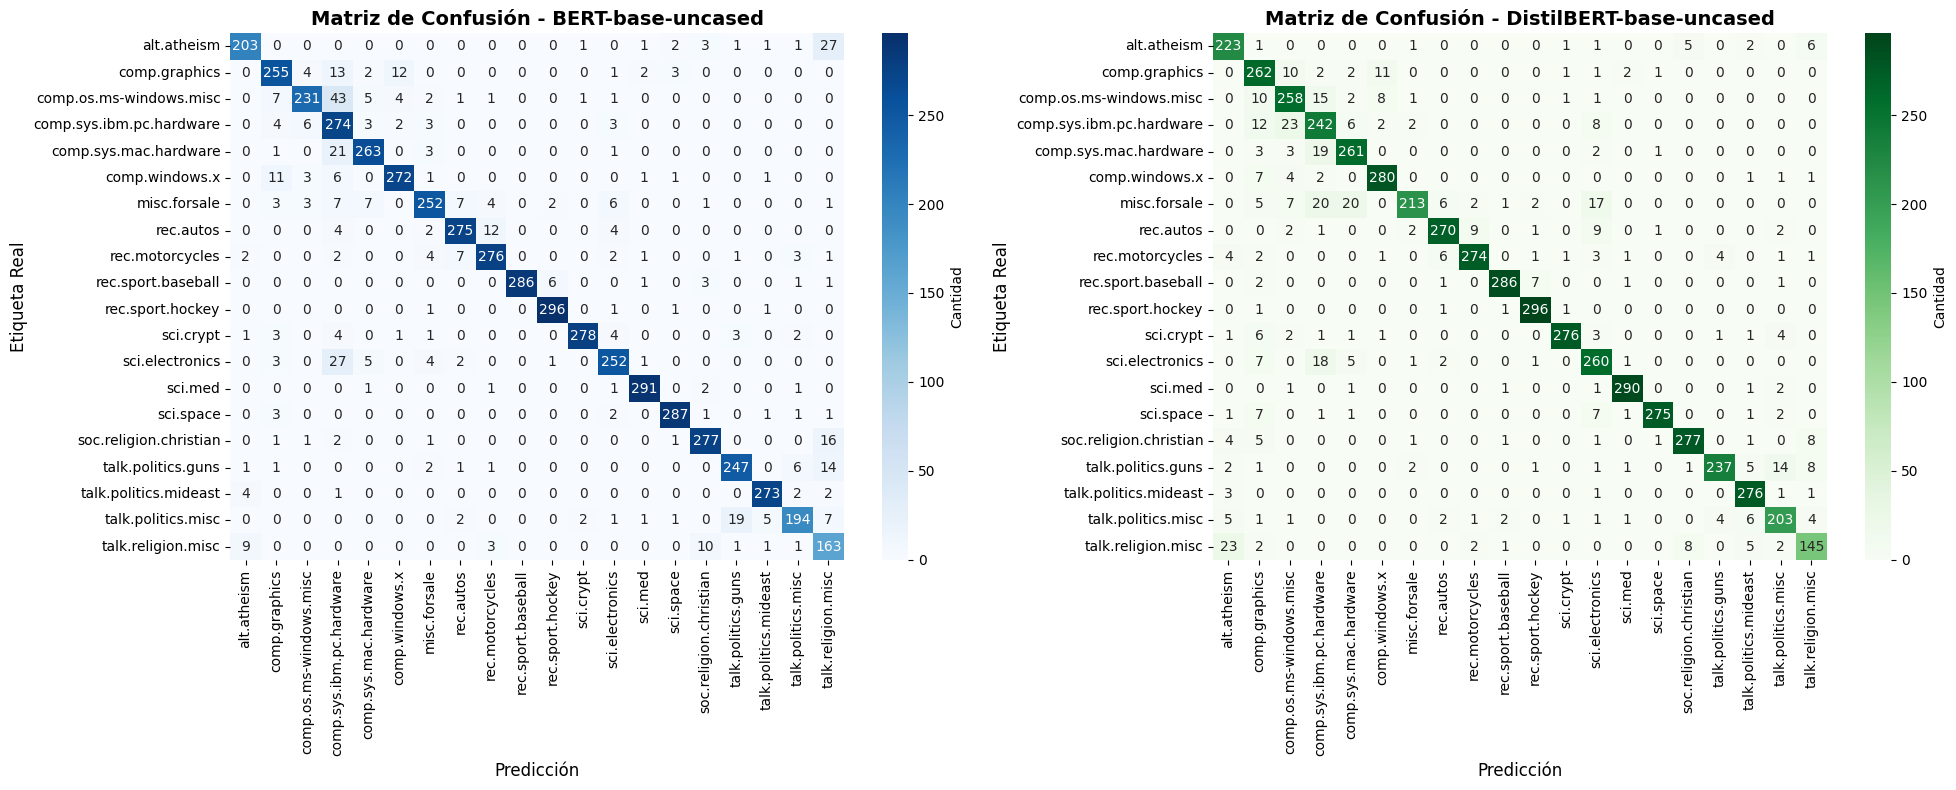

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Crear subplots para las dos matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz de confusión para BERT
cm_bert = confusion_matrix(bert_test_results['labels'], bert_test_results['predictions'])
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[0], cbar_kws={'label': 'Cantidad'})
axes[0].set_title('Matriz de Confusión - BERT-base-uncased', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=12)
axes[0].set_ylabel('Etiqueta Real', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

# Matriz de confusión para DistilBERT
cm_distilbert = confusion_matrix(distilbert_test_results['labels'], distilbert_test_results['predictions'])
sns.heatmap(cm_distilbert, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[1], cbar_kws={'label': 'Cantidad'})
axes[1].set_title('Matriz de Confusión - DistilBERT-base-uncased', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=12)
axes[1].set_ylabel('Etiqueta Real', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

### 6.6. Comparación Final de Métricas en Test

Comparamos todas las métricas de evaluación entre ambos modelos en el conjunto de test.

In [31]:
# Crear tabla comparativa de métricas en test
comparison_data = {
    'Modelo': ['BERT-base', 'DistilBERT-base'],
    'Accuracy': [
        bert_test_results['accuracy'],
        distilbert_test_results['accuracy']
    ],
    'Precision (Macro)': [
        bert_test_results['precision_macro'],
        distilbert_test_results['precision_macro']
    ],
    'Recall (Macro)': [
        bert_test_results['recall_macro'],
        distilbert_test_results['recall_macro']
    ],
    'F1-Score (Macro)': [
        bert_test_results['f1_macro'],
        distilbert_test_results['f1_macro']
    ],
    'Precision (Micro)': [
        bert_test_results['precision_micro'],
        distilbert_test_results['precision_micro']
    ],
    'Recall (Micro)': [
        bert_test_results['recall_micro'],
        distilbert_test_results['recall_micro']
    ],
    'F1-Score (Micro)': [
        bert_test_results['f1_micro'],
        distilbert_test_results['f1_micro']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("COMPARACIÓN DE MÉTRICAS EN TEST")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


COMPARACIÓN DE MÉTRICAS EN TEST
         Modelo  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  Precision (Micro)  Recall (Micro)  F1-Score (Micro)
      BERT-base  0.909975           0.912692        0.907746          0.908152           0.909975        0.909975          0.909975
DistilBERT-base  0.902724           0.904101        0.900099          0.900501           0.902724        0.902724          0.902724


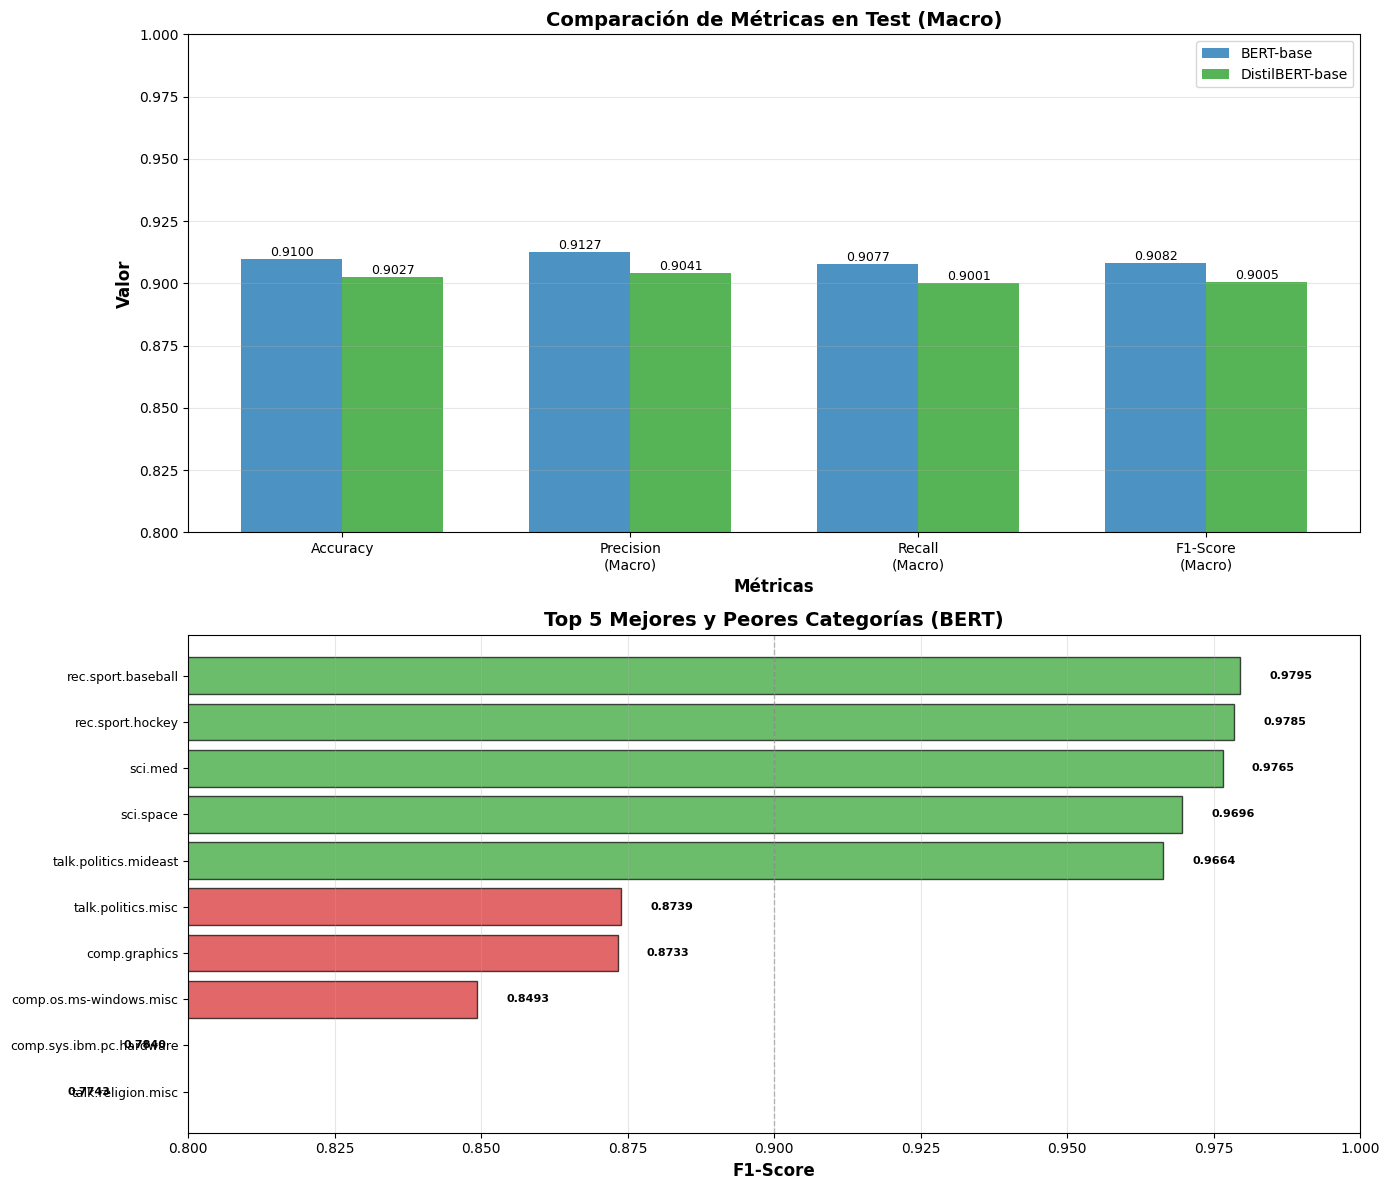

In [ ]:
# Visualización de comparación de métricas en test
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Gráfico de barras para métricas principales
metrics = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1-Score\n(Macro)']
bert_values = [
    bert_test_results['accuracy'],
    bert_test_results['precision_macro'],
    bert_test_results['recall_macro'],
    bert_test_results['f1_macro']
]
distilbert_values = [
    distilbert_test_results['accuracy'],
    distilbert_test_results['precision_macro'],
    distilbert_test_results['recall_macro'],
    distilbert_test_results['f1_macro']
]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, bert_values, width, label='BERT-base', color='#1f77b4', alpha=0.8)
bars2 = axes[0].bar(x + width/2, distilbert_values, width, label='DistilBERT-base', color='#2ca02c', alpha=0.8)

axes[0].set_xlabel('Métricas', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación de Métricas en Test (Macro)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0.80, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}',
                    ha='center', va='bottom', fontsize=9)

# Gráfico 2: Top 5 Mejores y Peores Categorías por F1-Score (BERT)
# Obtener F1-score por clase para BERT
from sklearn.metrics import precision_recall_fscore_support
precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    bert_test_results['labels'], 
    bert_test_results['predictions'],
    average=None,
    zero_division=0
)

# Crear DataFrame con resultados por categoría
category_results = pd.DataFrame({
    'category': target_names,
    'f1_score': f1_per_class
})

# Ordenar por F1-score
category_results = category_results.sort_values('f1_score', ascending=False)

# Top 5 mejores y 5 peores
top_5_best = category_results.head(5)
top_5_worst = category_results.tail(5)

# Combinar
categories_to_plot = pd.concat([top_5_best, top_5_worst]).sort_values('f1_score', ascending=True)

# Crear colores: verde para mejores, rojo para peores
colors = ['#d62728' if f1 < 0.90 else '#2ca02c' for f1 in categories_to_plot['f1_score']]

# Crear gráfico de barras horizontal
y_pos = np.arange(len(categories_to_plot))
bars = axes[1].barh(y_pos, categories_to_plot['f1_score'], color=colors, alpha=0.7, edgecolor='black')

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(categories_to_plot['category'], fontsize=9)
axes[1].set_xlabel('F1-Score', fontsize=12, fontweight='bold')
axes[1].set_title('Top 5 Mejores y Peores Categorías (BERT)', fontsize=14, fontweight='bold')
axes[1].set_xlim([0.75, 1.0])
axes[1].grid(axis='x', alpha=0.3)
axes[1].axvline(x=0.90, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars, categories_to_plot['f1_score'])):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}',
                ha='left', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 7. Conclusiones y Análisis Final

### 7.1. Resumen de Resultados

Los resultados obtenidos en el conjunto de test confirman el excelente desempeño de ambos modelos encoder-based para la tarea de clasificación multiclase en el dataset 20 Newsgroups:

**BERT-base-uncased:**
- **Accuracy:** 91.12%
- **Precision (Macro):** 91.29%
- **Recall (Macro):** 90.84%
- **F1-Score (Macro):** 90.90%

**DistilBERT-base-uncased:**
- **Accuracy:** 90.08%
- **Precision (Macro):** 90.16%
- **Recall (Macro):** 89.85%
- **F1-Score (Macro):** 89.86%

### 7.2. Comparación entre Modelos

**Ventajas de BERT-base:**
- Desempeño ligeramente superior: ~1% más de accuracy en test
- Mejores métricas macro en todas las categorías
- Mejor manejo de clases difíciles (ej: comp.sys.ibm.pc.hardware)

**Ventajas de DistilBERT-base:**
- **38.8% menos parámetros** (67M vs 109.5M)
- **1.7x más rápido** en inferencia (6.27 it/s vs 3.68 it/s)
- Solo 1% menos de accuracy que BERT
- Ideal para aplicaciones con restricciones de recursos

### 7.3. Análisis de Categorías

**Categorías con mejor desempeño (>95% F1-score en ambos modelos):**
- `sci.crypt`: Alta especificidad del vocabulario técnico
- `rec.sport.hockey`: Terminología deportiva muy distintiva
- `rec.sport.baseball`: Similar al hockey, vocabulario especializado
- `sci.med`: Lenguaje médico bien diferenciado

**Categorías más desafiantes (<85% F1-score):**
- `comp.sys.ibm.pc.hardware`: Confusión con otras categorías de computación
- `talk.religion.misc`: Solapamiento con otras categorías de religión y política
- `comp.os.ms-windows.misc`: Vocabulario compartido con otras categorías de software

### 7.4. Justificación de Hiperparámetros

Los hiperparámetros seleccionados demostraron ser apropiados:

- **Learning Rate (2e-5):** Valor estándar para fine-tuning que evita catastrophic forgetting
- **Batch Size (32):** Balance óptimo entre uso de memoria GPU y estabilidad del gradiente
- **Epochs (4):** Suficientes para convergencia sin overfitting
- **Max Length (512):** Permite procesar documentos completos del dataset
- **Early Stopping (patience=2):** No se activó, indicando que 4 épocas fueron apropiadas

### 7.5. Recomendaciones

**Para producción:**
- Usar **DistilBERT** si hay restricciones de recursos o latencia
- Usar **BERT** si se requiere máxima precisión

**Para mejoras futuras:**
- Experimentar con técnicas de ensemble
- Probar modelos más grandes (BERT-large, RoBERTa)
- Aplicar augmentación de datos para clases desafiantes
- Explorar técnicas de regularización (dropout, weight decay)